# **EDA**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
df = pd.read_csv("../../data/porEmpresas/definitivos/INDEX_ALL_scrapped_filtrado.csv")
df

,ticker,headline,summary,article_text,topic
0,AAPL,UK pay growth slows and unemployment ticks hig...,The UK jobs market continues to show signs of ...,The UK jobs market continues to show signs of ...,Financial and Market News and Corporate Sales
1,AAPL,Rising pension age hits women hardest,Enabling people to work for longer can spell g...,New data from the Department from Work and Pen...,Informal / Conversational Lenguaje
2,AAPL,How to ask for changes at work if you are neur...,Advocating for yourself can help create a cult...,Asking for workplace accommodations is often e...,Informal / Conversational Lenguaje
3,AAPL,Apple announces major expansion of renewables ...,The tech giant has increased its involvement i...,Apple has announced a major expansion of its r...,Financial and Market News and Corporate Sales
4,AAPL,"1 Unstoppable Stock Poised to Join Nvidia, App...",Semiconductors form the foundation of the arti...,The advent of artificial intelligence (AI) les...,Business Growth and Cloud Infrastructure in th...
...,...,...,...,...,...
5155,TSLA,Social Buzz: Wallstreetbets Stocks Mostly High...,The most-talked-about stocks in the Reddit sub...,Social Buzz: Wallstreetbets Stocks Mostly High...,Stock Market and Trading
5156,TSLA,Electric Vehicles Today - Driving Growth: New ...,The electric vehicle (EV) plant construction m...,The electric vehicle (EV) plant construction m...,Stock Market and Trading
5157,TSLA,"China's Xpeng to recall 47,490 P7+ electric ca...",BEIJING (Reuters) -Chinese electric carmaker X...,BEIJING (Reuters) -Chinese electric carmaker X...,Financial and Market News and Corporate Sales
5158,TSLA,Vietnam vehicle market up slightly in August,Sharp rise in CV sales offset by weak passenge...,Vietnam’s new vehicle market expanded slightly...,Financial and Market News and Corporate Sales


In [5]:
cols_keep = ["topic","ticker", "headline", "summary", "article_text"]
df = df[cols_keep]

df = df.dropna(subset=["article_text", "headline"])

print("Columnas conservadas:", df.columns.tolist())
print("Total de registros tras limpieza:", len(df))
df.head(5)

Columnas conservadas: ['topic', 'ticker', 'headline', 'summary', 'article_text']
Total de registros tras limpieza: 5160


,topic,ticker,headline,summary,article_text
0,Financial and Market News and Corporate Sales,AAPL,UK pay growth slows and unemployment ticks hig...,The UK jobs market continues to show signs of ...,The UK jobs market continues to show signs of ...
1,Informal / Conversational Lenguaje,AAPL,Rising pension age hits women hardest,Enabling people to work for longer can spell g...,New data from the Department from Work and Pen...
2,Informal / Conversational Lenguaje,AAPL,How to ask for changes at work if you are neur...,Advocating for yourself can help create a cult...,Asking for workplace accommodations is often e...
3,Financial and Market News and Corporate Sales,AAPL,Apple announces major expansion of renewables ...,The tech giant has increased its involvement i...,Apple has announced a major expansion of its r...
4,Business Growth and Cloud Infrastructure in th...,AAPL,"1 Unstoppable Stock Poised to Join Nvidia, App...",Semiconductors form the foundation of the arti...,The advent of artificial intelligence (AI) les...


## **EXPLORACIÓN GENERAL (NULLS, DUPLICADOS,...)**

In [ ]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5160 entries, 0 to 5159
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   topic         5160 non-null   object
 1   ticker        5160 non-null   object
 2   headline      5160 non-null   object
 3   summary       5160 non-null   object
 4   article_text  5160 non-null   object
dtypes: object(5)
memory usage: 201.7+ KB


In [9]:
nulos = df.isnull().sum()
nulos_porcentaje = (df.isnull().sum() / len(df)) * 100
nulos_df = pd.DataFrame({'Total Nulos': nulos, 'Porcentaje (%)': nulos_porcentaje}).sort_values(by='Total Nulos', ascending=False)
print(nulos_df)

total_duplicados = df.duplicated().sum()
print(f"Total de filas completamente duplicadas: {total_duplicados}")

if total_duplicados > 0:
    print("Considera eliminar duplicados con: df.drop_duplicates(inplace=True)")

              Total Nulos  Porcentaje (%)
topic                   0             0.0
ticker                  0             0.0
headline                0             0.0
summary                 0             0.0
article_text            0             0.0
Total de filas completamente duplicadas: 0


A pesar de haber filtrado en las distintas etapas de la creación del dataset, con esto verificamos que nuestro dataset es libre de posibles errores con valores nulos y duplicados a la hora de los siguientes procesos a seguir

## **DISTRIBUCIÓN DE EMPRESAS(TICKER)**

Número de tickers únicos: 18

Top 10 tickers más frecuentes:
ticker
AAPL     748
MSFT     744
GOOGL    731
AMZN     727
META     700
TSLA     679
NVDA     668
MRNA      41
CABGY     38
IAS       38
Name: count, dtype: int64


C:\Users\mpsua\AppData\Local\Temp\ipykernel_25936\3718581844.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ticker_counts.head(10).index, y=ticker_counts.head(10).values, palette='plasma')


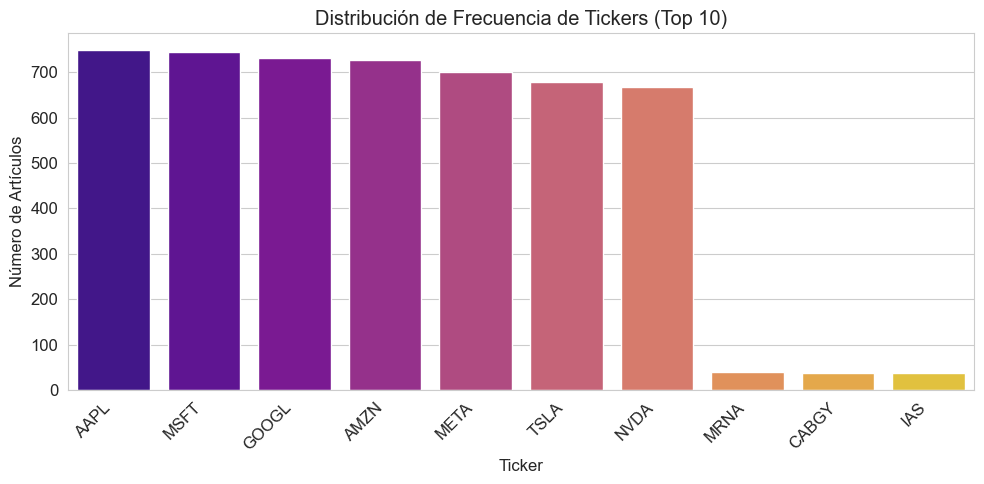

In [15]:
ticker_counts = df['ticker'].value_counts()
num_unique_tickers = df['ticker'].nunique()

print(f"Número de tickers únicos: {num_unique_tickers}")
print("\nTop 10 tickers más frecuentes:")
print(ticker_counts.head(10))

# Visualización de la distribución del ticker (Top 10)
plt.figure(figsize=(10, 5))
sns.barplot(x=ticker_counts.head(10).index, y=ticker_counts.head(10).values, palette='plasma')
plt.title('Distribución de Frecuencia de Tickers (Top 10)')
plt.xlabel('Ticker')
plt.ylabel('Número de Artículos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

De las 1000 que teníamos de las grandes empresas, hemos visto que al filtrar noticias cortas o con errores al hacer el scraping nos hemos quedado con mas de 700 en el mejor de los casos.

## **Defining Topics**

Número de temas únicos: 5
topic
Financial and Market News and Corporate Sales                  2257
Business Growth and Cloud Infrastructure in the AI Industry    1539
Stock Market and Trading                                       1111
Informal / Conversational Lenguaje                              152
Quantum Computing and Military Technology                       101
Name: count, dtype: int64


C:\Users\mpsua\AppData\Local\Temp\ipykernel_25936\3238411728.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=topic_counts.index, x=topic_counts.values, orient='h', palette='viridis')


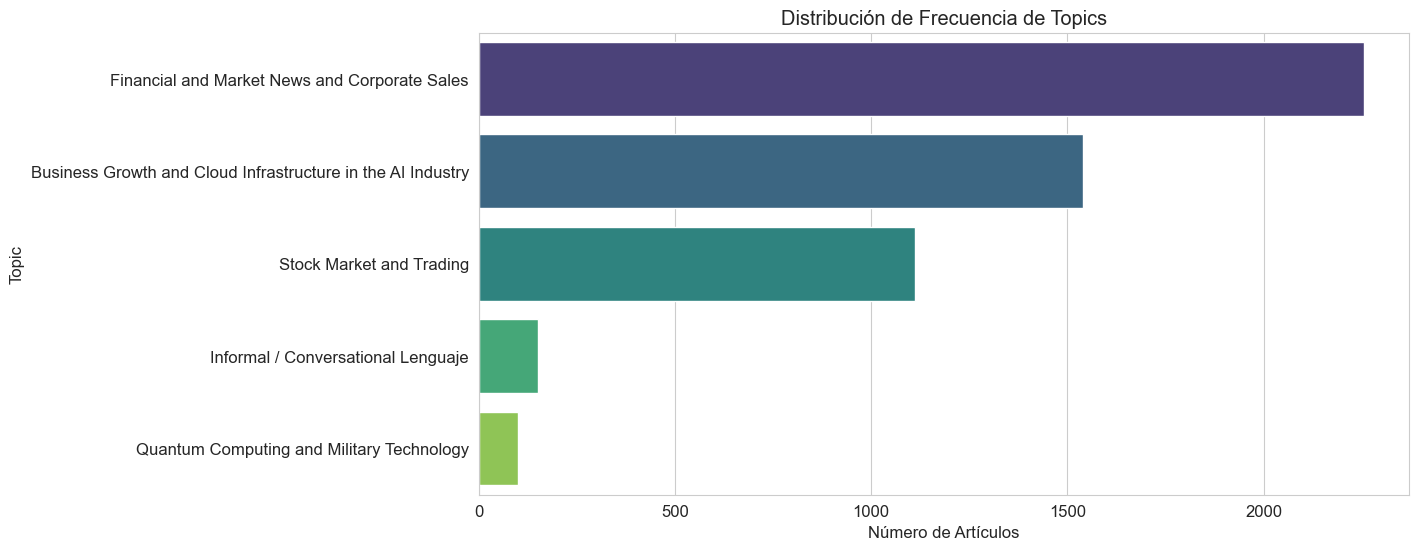

In [22]:
topic_counts = df['topic'].value_counts()
num_unique_topics = df['topic'].nunique()

print(f"Número de temas únicos: {num_unique_topics}")
print(topic_counts.head(10))

# Visualización de la distribución del topic
plt.figure(figsize=(12, 6))
sns.barplot(y=topic_counts.index, x=topic_counts.values, orient='h', palette='viridis')
plt.title('Distribución de Frecuencia de Topics')
plt.xlabel('Número de Artículos')
plt.ylabel('Topic')
plt.show()

Hemos conseguido distinguir los textos en 5 grupos principales, en el que se puede observar como hay dos grupos a los que no pertenece una cantidad significativa de textos, por lo que mas adelante tendremos que tratar con ellos. ANtes, vamos a interpretar cual es el topico que engloba cada grupo de textos en base a las palabras mas repetidas y las que mas relacionan a los textos de cada grupo.

In [46]:
df.loc[df["topic"] == "0_ai_company_nvidia_billion", "topic"] = "Business Growth and Cloud Infrastructure in the AI Industry"
df.loc[df["topic"] == "1_think_going_just_like", "topic"] = "Informal / Conversational Lenguaje"
df.loc[df["topic"] == "2_company_year_u_ha", "topic"] = "Financial and Market News and Corporate Sales"
df.loc[df["topic"] == "3_quantum_market_warfare_technology", "topic"] = "Quantum Computing and Military Technology"
df.loc[df["topic"] == "4_stock_market_trading_investor", "topic"] = "Stock Market and Trading"

df.to_csv("../../data/porEmpresas/definitivos/INDEX_ALL_scrapped_filtrado.csv", index=False)

C:\Users\mpsua\AppData\Local\Temp\ipykernel_25936\1191853211.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tickers.values, y=top_tickers.index, palette="Blues_d")


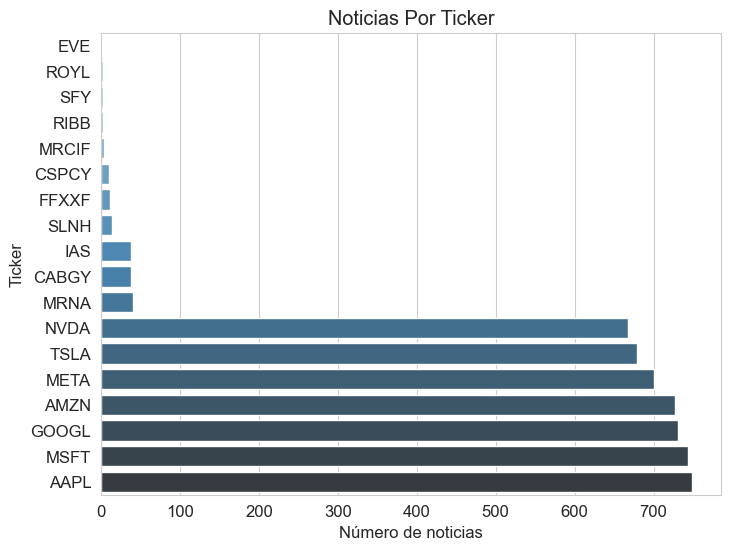

In [18]:
top_tickers = (
    df["ticker"]
    .value_counts()
    .head(20)
    .sort_values(ascending=True)
)

plt.figure(figsize=(8,6))
sns.barplot(x=top_tickers.values, y=top_tickers.index, palette="Blues_d")
plt.title("Noticias Por Ticker")
plt.xlabel("Número de noticias")
plt.ylabel("Ticker")
plt.show()

Se observa un fuerte desbalance en la distribución de topic, donde un único grupo representa más del 40% del corpus. Además, los nombres de los topics parecen generados automáticamente y no reflejan categorías financieras interpretables.

Teniendo esto en cuenta para tareas posteriores (clasificación de eventos), será necesario redefinir los topics manual o semiautomáticamente a partir del texto.